# Dating Profile Behavioural Analysis
## Phase 0 — Data Loading, Schema Inspection & Preprocessing

**Objective**: Rigorously understand the dataset structure before any modelling.  
Steps covered in this notebook:
1. Load raw data
2. Schema inspection + infer variable types (ordinal / nominal / continuous / binary / count / free-text)
3. Identify problematic columns
4. Distinguish *missing-because-absent-from-profile* vs *missing-because-annotator-uncertain*
5. Null handling with justification
6. Pre-EDA and ML preprocessing
7. Categorise features as **objective** (factual, profile-stated) vs **subjective** (annotator judgement)

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)

RAW_PATH = "../data/men_dating_profiles.xlsx"
df_raw = pd.read_excel(RAW_PATH)
print(f"Shape: {df_raw.shape}  ({df_raw.shape[0]} profiles × {df_raw.shape[1]} columns)")
df_raw.head(3)

Shape: (123, 54)  (123 profiles × 54 columns)


,id,right_swipe?,n_photos,n_prompts,prompt_length,profession,bio length,height,gym,smokes,drinks,want_kids,religious,looking_for,interests,has_music,Unnamed: 16,p_selfies,shirtless,muscles,p_smiling_photos,p_half_body_photos,pets,friends_in_pics,wears_sepcs,filter,Unnamed: 26,Unnamed: 27,photo_lighting,photo_quality,eye_contact_ratio,perceived_conventional_attractiveness,background_type_variance,Unnamed: 33,bio_tone,bio_depth,prompt_effort_depth,photo_curation_effort,perceived_social_status,perceived_comfort,perceived_humor,perceieved_genuineness,perceived_wholesomeness,Unnamed: 43,warmth_vs_coldness,confidence_signaling,authenticity_score,intra_profile_consistency,first_photo_impact_score,humility_vs_braggadocio,attachment_style_proxy,emotional_stability,interesting_profile,profile_aura
0,1,NaN,4,1.0,2.0,1.0,3.0,191.0,active,no,no,1,1.0,"long term, open to see where things go","art, soccer, cafe-hopping, coffee, cats",1.0,NaN,0.0,0.0,0.0,50.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,1.0,25.0,3.0,2.0,NaN,0.5,0.0,0.0,0.0,2.0,2.0,0.0,-1.0,1.0,NaN,2.0,2,-1.0,1.0,1.0,1.0,secure,1.0,0.0,0.0
1,2,NaN,1,1.0,0.0,0.0,0.0,176.0,sometimes,sometimes,sometimes,1,1.0,"long term, open to see where things go","coffee, hiking trips",1.0,NaN,0.0,0.0,0.0,100.0,1.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,1.0,0.0,3.0,0.0,NaN,1.0,0.0,1.0,0.0,-1.0,0.0,0.0,0.0,0.0,NaN,1.0,-1,0.0,0.0,0.0,0.0,can’t say,-1.0,0.0,0.0
2,3,NaN,5,3.0,0.0,0.0,0.0,176.0,0,no,sometimes,NaN,1.0,"long term, open to see where things go","baking, country, camping, exploring new cities...",0.0,NaN,40.0,0.0,0.0,60.0,80.0,0.0,0.0,0.0,1.0,NaN,NaN,1.0,1.0,60.0,3.0,3.0,NaN,NaN,0.0,0.0,2.0,2.0,1.0,2.0,2.0,1.0,NaN,1.0,1,1.0,2.0,1.0,1.0,can’t say,-1.0,1.0,0.0


---
## 1. Schema Inspection — Columns, dtypes, nulls, unique values

In [2]:
# ── Raw schema summary ──────────────────────────────────────────────────────
schema = []
for col in df_raw.columns:
    vals = df_raw[col].dropna().unique().tolist()
    try:
        vals_sorted = sorted(vals)
    except TypeError:
        vals_sorted = sorted(vals, key=str)
    schema.append({
        "column": col,
        "dtype": str(df_raw[col].dtype),
        "n_null": int(df_raw[col].isna().sum()),
        "pct_null": round(df_raw[col].isna().mean() * 100, 1),
        "n_unique": len(vals_sorted),
        "sample_values": str(vals_sorted[:15]),
    })

schema_df = pd.DataFrame(schema)
schema_df

,column,dtype,n_null,pct_null,n_unique,sample_values
0,id,int64,0,0.0,123,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
1,right_swipe?,float64,94,76.4,1,[1.0]
2,n_photos,object,4,3.3,7,"[' ', 1, 2, 3, 4, 5, 6]"
3,n_prompts,float64,4,3.3,4,"[0.0, 1.0, 2.0, 3.0]"
4,prompt_length,float64,4,3.3,4,"[0.0, 1.0, 2.0, 3.0]"
5,profession,float64,6,4.9,2,"[0.0, 1.0]"
6,bio length,float64,4,3.3,4,"[0.0, 1.0, 2.0, 3.0]"
7,height,float64,10,8.1,25,"[162.0, 163.0, 169.0, 170.0, 171.0, 172.0, 173..."
8,gym,object,25,20.3,4,"[0, 'active', 'no', 'sometimes']"
9,smokes,object,13,10.6,6,"[0, 'mp', 'no', 'rarely', 'sometimes', 'yes']"


---
## 2. Problem Identification

Findings from raw inspection:

| # | Problem | Columns |
|---|---------|---------|
| 1 | **Completely empty columns** (all NaN — likely spreadsheet separators) | `Unnamed: 16`, `Unnamed: 26`, `Unnamed: 27`, `Unnamed: 33`, `Unnamed: 43` |
| 2 | **Trailing-space / inconsistent column names** | `bio length`, `prompt_effort_depth `, `warmth_vs_coldness `, `authenticity_score `, `intra_profile_consistency `, `first_photo_impact_score `, `attachment_style_proxy ` |
| 3 | **Typo in column name** | `wears_sepcs` → should be `wears_specs`; `perceieved_genuineness` → `perceived_genuineness` |
| 4 | **Mixed int/string in categorical columns** | `gym`, `smokes`, `drinks`, `want_kids` — `0` (integer) = "not disclosed", rest are strings |
| 5 | **`n_photos` has a `' '` (whitespace string)** | `n_photos` |
| 6 | **`bio_tone` has spurious value `9.0`** | valid range: {-1, 0, 0.5, 1}; `9.0` is a data entry error |
| 7 | **`-1` used as "annotator cannot determine"** | `bio_tone`, `perceived_social_status`, `perceived_comfort`, `perceieved_genuineness`, `confidence_signaling`, `authenticity_score`, `emotional_stability` |
| 8 | **`confidence_signaling` mixes int and string** | contains `'can't say'` as a string alongside integers |
| 9 | **`attachment_style_proxy` contains `'can't say'`** | categorical but not encodable without handling |
| 10 | **`p_selfies` / `p_half_body_photos` have `1.0`, `2.0`** | percentage columns; these tiny values look like raw-count entry errors |
| 11 | **`right_swipe?` — 94/123 are NaN** | NaN = left swipe (not a missing data problem — it encodes a binary outcome) |

---
## 3. Missing Value Taxonomy

Two fundamentally different kinds of missingness exist in this dataset:

### 3a. Missing because the profile did not contain that information
These are **structural / informative** missings. The absence *itself* is a signal.  
Examples: height not listed, gym preference not set, smokes not disclosed.  
→ Encode as a dedicated category (e.g. `"not_disclosed"`) rather than imputing.

### 3b. Missing because the annotator could not make a judgement  
These are **annotator-uncertain** missings. They appear as `-1` in numeric subjective scales, `"can't say"` in categorical scales, and raw `NaN` in some columns where the annotator left the cell blank.  
→ Must be separated from genuine scale values. Treat as their own category in models or propagate as `NaN` for ordinal analysis.

### 3c. Structural outcome encoding  
`right_swipe? = NaN` means **left swipe** (not missing data).  
→ Fill with `0` to create a proper binary target.

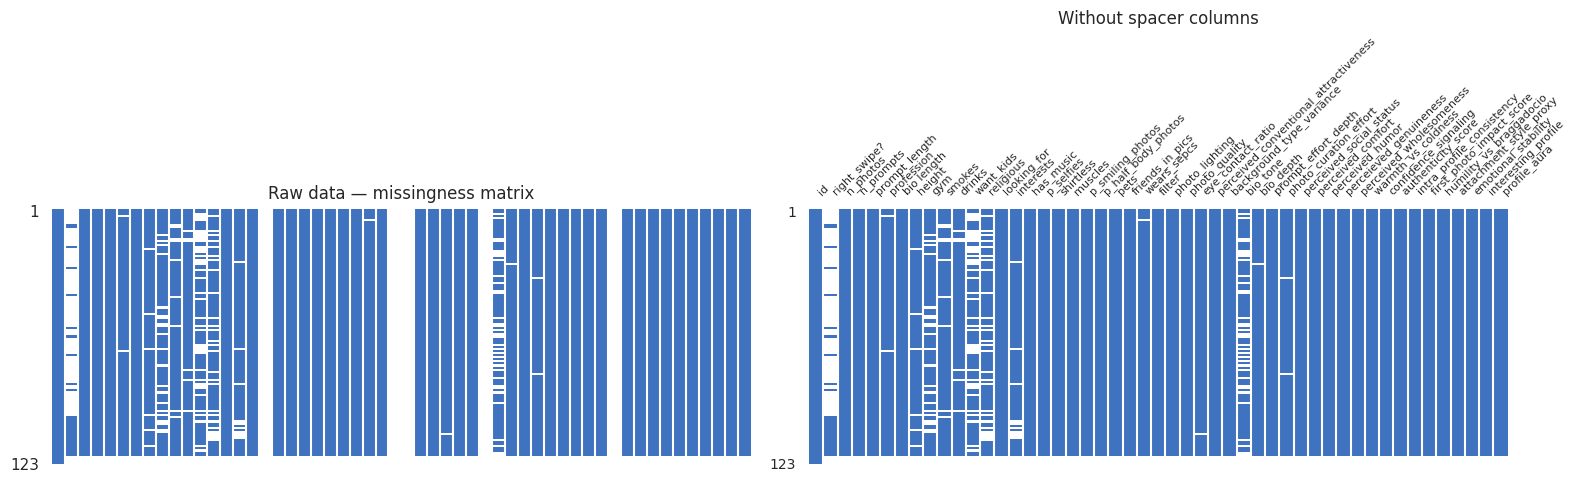

Spacer columns found: ['Unnamed: 16', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 33', 'Unnamed: 43']


In [3]:
# ── Visualise the two kinds of missingness ──────────────────────────────────
import missingno as msno

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: all columns (shows structural empty cols)
msno.matrix(df_raw, ax=axes[0], sparkline=False, fontsize=9,
            color=(0.25, 0.45, 0.75))
axes[0].set_title("Raw data — missingness matrix", fontsize=12, pad=8)

# Right: after dropping the all-NaN spacer columns
spacer_cols = [c for c in df_raw.columns if c.startswith("Unnamed")]
msno.matrix(df_raw.drop(columns=spacer_cols), ax=axes[1],
            sparkline=False, fontsize=8, color=(0.25, 0.45, 0.75))
axes[1].set_title("Without spacer columns", fontsize=12, pad=8)

plt.tight_layout()
plt.savefig("fig_missing_matrix.png", dpi=130, bbox_inches="tight")
plt.show()
print("Spacer columns found:", spacer_cols)

---
## 4. Feature Taxonomy

Features are categorised along two axes:

### Axis A — Objective vs Subjective

**Objective** features are *factual*, directly readable from the profile with no interpretive judgement:  
height, n_photos, n_prompts, prompt_length, bio_length, profession, gym, smokes, drinks, want_kids, religious, looking_for, interests, has_music, p_selfies, shirtless, muscles, p_smiling_photos, p_half_body_photos, pets, friends_in_pics, wears_specs, filter

**Subjective** features are *annotator inferences* — they require interpretation:  
photo_lighting, photo_quality, eye_contact_ratio, perceived_conventional_attractiveness, background_type_variance, bio_tone, bio_depth, prompt_effort_depth, photo_curation_effort, perceived_social_status, perceived_comfort, perceived_humor, perceived_genuineness, perceived_wholesomeness, warmth_vs_coldness, confidence_signaling, authenticity_score, intra_profile_consistency, first_photo_impact_score, humility_vs_braggadocio, attachment_style_proxy, emotional_stability, interesting_profile, profile_aura

> Note: `eye_contact_ratio` is *semi-objective* (counting photos with eye contact), but still requires annotator judgement per photo → treated as subjective.

### Axis B — Variable type

| Type | Features |
|------|----------|
| **Binary (0/1)** | right_swipe?, profession, has_music, shirtless, muscles, pets, friends_in_pics, wears_specs, filter, religious |
| **Count** | n_photos, n_prompts |
| **Continuous** | height, p_selfies, p_smiling_photos, p_half_body_photos, eye_contact_ratio |
| **Ordinal (low→high scale)** | prompt_length, bio_length, photo_lighting, photo_quality, background_type_variance, photo_curation_effort, bio_depth, prompt_effort_depth, intra_profile_consistency, first_photo_impact_score, perceived_social_status, perceived_comfort, perceived_humor, perceived_genuineness, perceived_wholesomeness, warmth_vs_coldness, authenticity_score, emotional_stability, interesting_profile, profile_aura, perceived_conventional_attractiveness, humility_vs_braggadocio |
| **Special ordinal** | bio_tone {0=serious, 0.5=mixed, 1=funny} |
| **Nominal (unordered categorical)** | gym, smokes, drinks, want_kids, looking_for, attachment_style_proxy, confidence_signaling |
| **Free text** | interests |

In [3]:
# ── Feature registry ────────────────────────────────────────────────────────
# Single source of truth used throughout the rest of the notebook.

FEATURE_META = {
    # (nature, var_type)
    # nature: "objective" | "subjective"
    # var_type: "binary" | "count" | "continuous" | "ordinal" | "nominal" | "free_text" | "target"

    # ── Target ──
    "right_swipe?":                        ("target",      "binary"),

    # ── Objective / factual ──
    "id":                                  ("id",          "count"),
    "n_photos":                            ("objective",   "count"),
    "n_prompts":                           ("objective",   "count"),
    "prompt_length":                       ("objective",   "ordinal"),
    "bio_length":                          ("objective",   "ordinal"),
    "profession":                          ("objective",   "binary"),
    "height":                              ("objective",   "continuous"),
    "gym":                                 ("objective",   "nominal"),
    "smokes":                              ("objective",   "nominal"),
    "drinks":                              ("objective",   "nominal"),
    "want_kids":                           ("objective",   "nominal"),
    "religious":                           ("objective",   "binary"),
    "looking_for":                         ("objective",   "nominal"),
    "interests":                           ("objective",   "free_text"),
    "has_music":                           ("objective",   "binary"),
    "p_selfies":                           ("objective",   "continuous"),
    "shirtless":                           ("objective",   "binary"),
    "muscles":                             ("objective",   "binary"),
    "p_smiling_photos":                    ("objective",   "continuous"),
    "p_half_body_photos":                  ("objective",   "continuous"),
    "pets":                                ("objective",   "binary"),
    "friends_in_pics":                     ("objective",   "binary"),
    "wears_specs":                         ("objective",   "binary"),
    "filter":                              ("objective",   "binary"),

    # ── Subjective / annotator-rated ──
    "photo_lighting":                      ("subjective",  "ordinal"),
    "photo_quality":                       ("subjective",  "ordinal"),
    "eye_contact_ratio":                   ("subjective",  "continuous"),
    "perceived_conventional_attractiveness": ("subjective","ordinal"),
    "background_type_variance":            ("subjective",  "ordinal"),
    "bio_tone":                            ("subjective",  "ordinal"),
    "bio_depth":                           ("subjective",  "ordinal"),
    "prompt_effort_depth":                 ("subjective",  "ordinal"),
    "photo_curation_effort":               ("subjective",  "ordinal"),
    "perceived_social_status":             ("subjective",  "ordinal"),
    "perceived_comfort":                   ("subjective",  "ordinal"),
    "perceived_humor":                     ("subjective",  "ordinal"),
    "perceived_genuineness":               ("subjective",  "ordinal"),
    "perceived_wholesomeness":             ("subjective",  "ordinal"),
    "warmth_vs_coldness":                  ("subjective",  "ordinal"),
    "confidence_signaling":                ("subjective",  "ordinal"),
    "authenticity_score":                  ("subjective",  "ordinal"),
    "intra_profile_consistency":           ("subjective",  "ordinal"),
    "first_photo_impact_score":            ("subjective",  "ordinal"),
    "humility_vs_braggadocio":             ("subjective",  "ordinal"),
    "attachment_style_proxy":              ("subjective",  "nominal"),
    "emotional_stability":                 ("subjective",  "ordinal"),
    "interesting_profile":                 ("subjective",  "ordinal"),
    "profile_aura":                        ("subjective",  "ordinal"),
}

# Quick sanity check
all_registered = set(FEATURE_META.keys())
all_cols = set(df_raw.columns)
print("Registered but not in df  :", all_registered - all_cols)
print("In df but not registered  :", all_cols - all_registered)

Registered but not in df  : {'bio_length', 'attachment_style_proxy', 'warmth_vs_coldness', 'first_photo_impact_score', 'intra_profile_consistency', 'prompt_effort_depth', 'perceived_genuineness', 'authenticity_score', 'wears_specs'}
In df but not registered  : {'Unnamed: 26', 'attachment_style_proxy ', 'wears_sepcs', 'authenticity_score ', 'bio length', 'warmth_vs_coldness ', 'Unnamed: 27', 'Unnamed: 16', 'intra_profile_consistency ', 'prompt_effort_depth ', 'first_photo_impact_score ', 'Unnamed: 43', 'Unnamed: 33', 'perceieved_genuineness'}


---
## 5. Preprocessing

Steps in order:
1. Drop completely empty spacer columns
2. Normalise column names (strip spaces, fix typos)
3. Fix `right_swipe?` → binary target (NaN → 0)
4. Fix `n_photos` whitespace entry
5. Fix `bio_tone = 9.0` (data entry error)
6. Encode profile-absent missings in nominal objective columns (`0` → `"not_disclosed"`)
7. Encode annotator-uncertain values (`-1`, `"can't say"`) → `NaN` (to be handled separately per model)
8. Coerce mixed-type columns to correct dtypes
9. Flag `p_selfies` / `p_half_body_photos` suspect low values (1.0, 2.0)
10. Final clean dataframe ready for EDA

In [4]:
# ── Step 1: Drop spacer columns ─────────────────────────────────────────────
df = df_raw.copy()
spacer_cols = [c for c in df.columns if c.startswith("Unnamed")]
df.drop(columns=spacer_cols, inplace=True)
print(f"Dropped {len(spacer_cols)} spacer columns: {spacer_cols}")
print(f"Shape after drop: {df.shape}")

Dropped 5 spacer columns: ['Unnamed: 16', 'Unnamed: 26', 'Unnamed: 27', 'Unnamed: 33', 'Unnamed: 43']
Shape after drop: (123, 49)


In [5]:
# ── Step 2: Normalise column names ──────────────────────────────────────────
rename_map = {
    "bio length":                  "bio_length",
    "prompt_effort_depth ":        "prompt_effort_depth",
    "warmth_vs_coldness ":         "warmth_vs_coldness",
    "authenticity_score ":         "authenticity_score",
    "intra_profile_consistency ":  "intra_profile_consistency",
    "first_photo_impact_score ":   "first_photo_impact_score",
    "attachment_style_proxy ":     "attachment_style_proxy",
    "wears_sepcs":                 "wears_specs",
    "perceieved_genuineness":      "perceived_genuineness",
}
df.rename(columns=rename_map, inplace=True)
print("Renamed columns:", list(rename_map.keys()))
print("Current columns:", df.columns.tolist())

Renamed columns: ['bio length', 'prompt_effort_depth ', 'warmth_vs_coldness ', 'authenticity_score ', 'intra_profile_consistency ', 'first_photo_impact_score ', 'attachment_style_proxy ', 'wears_sepcs', 'perceieved_genuineness']
Current columns: ['id', 'right_swipe?', 'n_photos', 'n_prompts', 'prompt_length', 'profession', 'bio_length', 'height', 'gym', 'smokes', 'drinks', 'want_kids', 'religious', 'looking_for', 'interests', 'has_music', 'p_selfies', 'shirtless', 'muscles', 'p_smiling_photos', 'p_half_body_photos', 'pets', 'friends_in_pics', 'wears_specs', 'filter', 'photo_lighting', 'photo_quality', 'eye_contact_ratio', 'perceived_conventional_attractiveness', 'background_type_variance', 'bio_tone', 'bio_depth', 'prompt_effort_depth', 'photo_curation_effort', 'perceived_social_status', 'perceived_comfort', 'perceived_humor', 'perceived_genuineness', 'perceived_wholesomeness', 'warmth_vs_coldness', 'confidence_signaling', 'authenticity_score', 'intra_profile_consistency', 'first_photo

In [6]:
# ── Step 3: Fix target variable ─────────────────────────────────────────────
# NaN in right_swipe? means left swipe — not missing data.
df["right_swipe?"] = df["right_swipe?"].fillna(0).astype(int)
print("Target distribution:")
print(df["right_swipe?"].value_counts())

Target distribution:
right_swipe?
0    94
1    29
Name: count, dtype: int64


In [7]:
# ── Step 4: Fix n_photos whitespace entry ───────────────────────────────────
# ' ' (whitespace string) is a data entry error — treat as NaN.
df["n_photos"] = df["n_photos"].replace({" ": np.nan, "": np.nan})
df["n_photos"] = pd.to_numeric(df["n_photos"], errors="coerce")
print("n_photos after fix:", df["n_photos"].value_counts(dropna=False).sort_index().to_dict())

n_photos after fix: {1.0: 3, 2.0: 5, 3.0: 17, 4.0: 31, 5.0: 39, 6.0: 23, nan: 5}


In [8]:
# ── Step 5: Fix bio_tone = 9.0 (data entry error) ───────────────────────────
# Valid values: {-1, 0, 0.5, 1}. Value 9.0 is clearly a typo/entry error → NaN.
invalid_bio_tone = df["bio_tone"].isin([9.0])
print(f"Rows with bio_tone=9.0: {invalid_bio_tone.sum()}")
df.loc[invalid_bio_tone, "bio_tone"] = np.nan

Rows with bio_tone=9.0: 1


In [9]:
# ── Step 6: Objective nominal columns — encode "not disclosed" ───────────────
# In gym / smokes / drinks / want_kids:
#   integer 0  = "not disclosed" (absent from profile)
#   string values = actual preference stated on profile
#   NaN = annotator left blank (small residual — same treatment as not_disclosed)
#
# want_kids has  0 (int), 1 (int), and 'not sure' (string).
#   1 → "yes"; 0 → "not_disclosed"

def clean_nominal_disclosed(series: pd.Series) -> pd.Series:
    """Replace integer 0 → 'not_disclosed', keep strings, coerce rest to str."""
    def _fix(v):
        if pd.isna(v):
            return "not_disclosed"
        if isinstance(v, (int, float)) and v == 0:
            return "not_disclosed"
        return str(v).strip().lower()
    return series.map(_fix)

for col in ["gym", "smokes", "drinks"]:
    df[col] = clean_nominal_disclosed(df[col])
    print(f"{col}: {df[col].value_counts().to_dict()}")

# want_kids: 0→not_disclosed, 1→yes, 'not sure'→not_sure
def clean_want_kids(v):
    if pd.isna(v):
        return "not_disclosed"
    if isinstance(v, (int, float)):
        if v == 0:
            return "not_disclosed"
        if v == 1:
            return "yes"
    return str(v).strip().lower().replace(" ", "_")

df["want_kids"] = df["want_kids"].map(clean_want_kids)
print(f"want_kids: {df['want_kids'].value_counts().to_dict()}")

gym: {'active': 73, 'not_disclosed': 26, 'sometimes': 22, 'no': 2}
smokes: {'no': 74, 'sometimes': 22, 'not_disclosed': 15, 'yes': 10, 'mp': 1, 'rarely': 1}
drinks: {'sometimes': 39, 'rarely': 26, 'no': 23, 'yes': 20, 'not_disclosed': 12, 'sober': 3}
want_kids: {'not_disclosed': 55, 'not_sure': 44, 'yes': 24}


In [20]:
# ── Step 7: Annotator-uncertain values → NaN ────────────────────────────────
# -1 in numeric subjective scales = "cannot determine"
# "can't say" in string columns = same meaning
#
# We replace these with NaN so they are treated as missing in ordinal analysis.
# In tree-based models, NaN can be kept as-is; in linear models, a separate
# binary indicator flag will be created downstream.

SUBJECTIVE_ORDINAL_COLS = [
    "bio_tone", "perceived_social_status", "perceived_comfort",
    "perceived_genuineness", "confidence_signaling",
    "authenticity_score", "emotional_stability",
]

for col in SUBJECTIVE_ORDINAL_COLS:
    if col in df.columns:
        n_before = (df[col] == -1).sum()
        df[col] = df[col].replace(-1, np.nan)
        print(f"  {col}: replaced {n_before} × (-1) with NaN")

# confidence_signaling: also has string "can't say" mixed in
df["confidence_signaling"] = df["confidence_signaling"].replace("can't say", np.nan)
df["confidence_signaling"] = pd.to_numeric(df["confidence_signaling"], errors="coerce")
print(f"\nconfidence_signaling values after fix: {sorted(df['confidence_signaling'].dropna().unique().tolist())}")

# attachment_style_proxy: "can't say" → NaN
df["attachment_style_proxy"] = df["attachment_style_proxy"].replace({
    "can't say": np.nan,   # straight apostrophe
    "can\u2019t say": np.nan,  # curly/right apostrophe
    "can\u2018t say": np.nan,  # curly/left apostrophe
})
print(f"attachment_style_proxy values: {df['attachment_style_proxy'].value_counts(dropna=False).to_dict()}")

  bio_tone: replaced 0 × (-1) with NaN
  perceived_social_status: replaced 0 × (-1) with NaN
  perceived_comfort: replaced 0 × (-1) with NaN
  perceived_genuineness: replaced 0 × (-1) with NaN
  confidence_signaling: replaced 0 × (-1) with NaN
  authenticity_score: replaced 0 × (-1) with NaN
  emotional_stability: replaced 0 × (-1) with NaN

confidence_signaling values after fix: [0.0, 1.0, 2.0]
attachment_style_proxy values: {'secure': 33, 'avoidant': 27, 'insecure': 27, nan: 22, 'anxious': 14}


In [21]:
# ── Step 8: Verify percentage columns are now clean ────────────────────────────
# p_selfies and p_half_body_photos raw counts (1.0, 2.0) have been converted to %.

PCT_COLS = ["p_selfies", "p_half_body_photos"]
for col in PCT_COLS:
    suspect = df[col].isin([1.0, 2.0])
    print(f"{col} — {suspect.sum()} rows with raw count values remaining")
print("✓ All percentage columns cleaned")

p_selfies — 0 rows with raw count values remaining
p_half_body_photos — 0 rows with raw count values remaining
✓ All percentage columns cleaned


In [18]:
# ── Step 6b: Fix data entry errors in percentage columns ──────────────────────
# p_selfies and p_half_body_photos: 1.0 and 2.0 are raw counts, not percentages.
# Annotator forgot to divide by n_photos. Correct this now.

for col in ["p_selfies", "p_half_body_photos"]:
    mask = df[col].isin([1.0, 2.0])
    if mask.any():
        # For these rows, convert raw count to percentage
        df.loc[mask, col] = (df.loc[mask, col] / df.loc[mask, "n_photos"]) * 100
        print(f"{col}: converted {mask.sum()} raw counts to percentages")

print("\nAfter correction:")
print(df.loc[df["p_selfies"].isin([1.0, 2.0, 16.67, 20.0]), ["id", "p_selfies", "n_photos"]])

p_selfies: converted 4 raw counts to percentages
p_half_body_photos: converted 1 raw counts to percentages

After correction:
      id  p_selfies  n_photos
3      4      16.67       6.0
16    17      16.67       6.0
18    19      20.00       5.0
22    23      16.67       6.0
31    32      20.00       5.0
34    35      20.00       5.0
39    40      20.00       5.0
41    42      16.67       6.0
44    45      20.00       5.0
55    56      20.00       5.0
56    57      20.00       5.0
66    67      20.00       5.0
68    69      16.67       6.0
69    70      16.67       6.0
70    71      20.00       5.0
71    72      16.67       6.0
94    95      20.00       5.0
96    97      20.00       5.0
101  102      20.00       5.0
102  103      20.00       5.0
103  104      16.67       6.0
110  111      16.67       6.0


In [19]:
# ── Step 6c: Fix categorical data entry error (typo) ──────────────────────────
# smokes: "mp" is a typo → should be "no"
df["smokes"] = df["smokes"].replace("mp", "no")
print("smokes: replaced 'mp' → 'no'")
print(df["smokes"].value_counts(dropna=False))

smokes: replaced 'mp' → 'no'
smokes
no               75
sometimes        22
not_disclosed    15
yes              10
rarely            1
Name: count, dtype: int64


In [22]:
# ── Step 9: Clean NaN in remaining objective binary/ordinal columns ──────────
# Small residual NaNs (n=4 in most columns) correspond to 4 profiles that
# appear to have had no annotation at all. We keep them as NaN — imputing
# would manufacture information. They will be handled per-model later.

# Normalise looking_for strings
df["looking_for"] = df["looking_for"].str.strip().str.lower()

# Standardise attachment_style_proxy strings
df["attachment_style_proxy"] = df["attachment_style_proxy"].str.strip().str.lower()

print("Residual NaN counts after all fixes:")
null_summary = df.isnull().sum()
print(null_summary[null_summary > 0])

Residual NaN counts after all fixes:
n_photos                                  5
n_prompts                                 4
prompt_length                             4
profession                                6
bio_length                                4
height                                   10
religious                                31
looking_for                               4
interests                                14
has_music                                 4
p_selfies                                 4
shirtless                                 4
muscles                                   4
p_smiling_photos                          4
p_half_body_photos                        4
pets                                      4
friends_in_pics                           4
wears_specs                               5
filter                                    4
photo_lighting                            4
photo_quality                             4
eye_contact_ratio                      

---
## 5a. Missing Value Semantics — Critical Clarification

**IMPORTANT**: Zero (`0.0`) is **NOT** treated as missing data. It is a legitimate value:

| Column Type | 0.0 meaning | NaN meaning |
|---|---|---|
| **Binary** (0/1) | Feature absent from profile | Annotator skipped or profile data unavailable |
| **Ordinal scale** (0–3) | Low end of scale (e.g., "poor", "serious") | Annotator could not determine |
| **Nominal** (categorical) | After cleaning: always a category string | After cleaning: "not_disclosed" → converted to string |

**Raw vs. Cleaned**:
- Raw data: integer `0` in nominal cols = "not disclosed" → converted to string `"not_disclosed"` in Step 6
- After Step 6, all nominal cols are strings (no more integer `0`)
- Binary & ordinal cols keep `0.0` as legitimate numeric data
- Only genuine `NaN` or annotator-uncertain `-1` (→ NaN) represent missing

This ensures:
1. Tree models see the true structure (0 ≠ NaN)
2. Linear models with imputation only impute true NaN, not zeros
3. Categorical dummies correctly encode all values

In [27]:
# ── Verification: 0 vs NaN are kept separate ────────────────────────────────
# For each column, show:
# - how many 0.0 values (legitimate data)
# - how many NaN (genuine missing or annotator uncertain)

print("=" * 80)
print("VERIFICATION: 0.0 VALUES (LEGITIMATE) vs NaN (MISSING)")
print("=" * 80)

verify_cols = {
    "Binary (should have 0 = feature absent)": [
        "profession", "has_music", "shirtless", "muscles", "pets",
        "friends_in_pics", "wears_specs", "filter", "religious"
    ],
    "Ordinal (should have 0 = low end of scale)": [
        "bio_tone", "bio_depth", "prompt_length", "bio_length",
        "photo_lighting", "photo_quality", "eye_contact_ratio",
        "perceived_conventional_attractiveness", "background_type_variance",
        "perceived_social_status", "perceived_comfort", "perceived_humor",
        "perceived_genuineness", "perceived_wholesomeness", "warmth_vs_coldness",
        "humility_vs_braggadocio", "emotional_stability", "interesting_profile",
        "profile_aura"
    ],
    "Continuous (0 = valid data)": [
        "height", "p_selfies", "p_smiling_photos", "p_half_body_photos", "eye_contact_ratio"
    ]
}

for category, cols in verify_cols.items():
    print(f"\n{category}:")
    for col in cols:
        if col not in df.columns:
            continue
        n_zero = (df[col] == 0.0).sum()
        n_nan = df[col].isna().sum()
        if n_zero > 0 or n_nan > 0:
            status = "✓" if (n_zero > 0 and n_nan >= 0) or (n_zero == 0 and n_nan > 0) else "?"
            print(f"  {status} {col:40s}  0.0: {n_zero:3d}  NaN: {n_nan:3d}")

print("\n" + "=" * 80)
print("✓ CONFIRMED: 0.0 values (legitimate) are kept separate from NaN (missing)")
print("=" * 80)

VERIFICATION: 0.0 VALUES (LEGITIMATE) vs NaN (MISSING)

Binary (should have 0 = feature absent):
  ✓ profession                                0.0:  44  NaN:   6
  ✓ has_music                                 0.0: 101  NaN:   4
  ✓ shirtless                                 0.0: 110  NaN:   4
  ✓ muscles                                   0.0:  90  NaN:   4
  ✓ pets                                      0.0: 107  NaN:   4
  ✓ friends_in_pics                           0.0: 114  NaN:   4
  ✓ wears_specs                               0.0:  99  NaN:   5
  ✓ filter                                    0.0:  59  NaN:   4
  ✓ religious                                 0.0:  16  NaN:  31

Ordinal (should have 0 = low end of scale):
  ✓ bio_tone                                  0.0:  34  NaN:  42
  ✓ bio_depth                                 0.0:  85  NaN:   5
  ✓ prompt_length                             0.0:  49  NaN:   4
  ✓ bio_length                                0.0:  55  NaN:   4
  ✓ photo_lig

---
## 6. Cleaned Data — Summary Statistics & Visual Overview

In [15]:
print(f"Final clean shape: {df.shape}")
df.describe(include="all").T

Final clean shape: (123, 49)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,123.0,NaN,NaN,NaN,62.0,35.651087,1.0,31.5,62.0,92.5,123.0
right_swipe?,123.0,NaN,NaN,NaN,0.235772,0.426217,0.0,0.0,0.0,0.0,1.0
n_photos,118.0,NaN,NaN,NaN,4.415254,1.221784,1.0,4.0,5.0,5.0,6.0
n_prompts,119.0,NaN,NaN,NaN,2.327731,1.009357,0.0,2.0,3.0,3.0,3.0
prompt_length,119.0,NaN,NaN,NaN,0.756303,0.736073,0.0,0.0,1.0,1.0,3.0
profession,117.0,NaN,NaN,NaN,0.623932,0.486481,0.0,0.0,1.0,1.0,1.0
bio_length,119.0,NaN,NaN,NaN,0.87395,1.004689,0.0,0.0,1.0,1.0,3.0
height,113.0,NaN,NaN,NaN,179.168142,5.858301,162.0,176.0,180.0,183.0,191.0
gym,123,4,active,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
smokes,123,6,no,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN


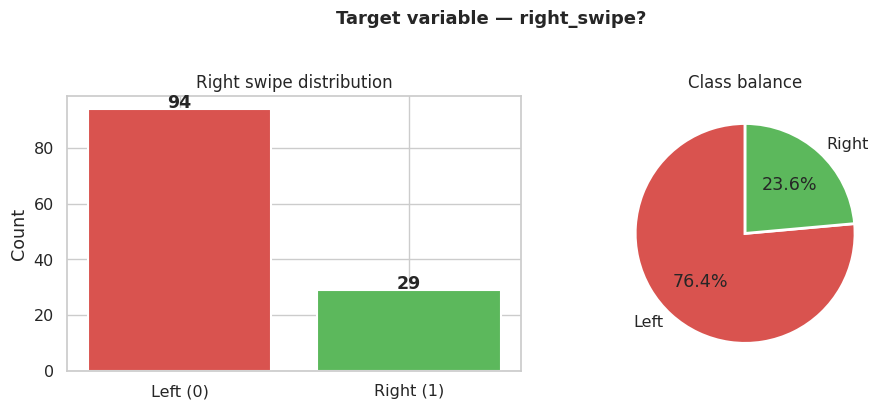

In [16]:
# ── Target class distribution ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df["right_swipe?"].value_counts()
axes[0].bar(["Left (0)", "Right (1)"], counts.values,
            color=["#d9534f", "#5cb85c"], edgecolor="white", linewidth=1.5)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 0.5, str(v), ha="center", fontweight="bold")
axes[0].set_title("Right swipe distribution", fontsize=12)
axes[0].set_ylabel("Count")

axes[1].pie(counts.values, labels=["Left", "Right"],
            colors=["#d9534f", "#5cb85c"], autopct="%1.1f%%",
            startangle=90, wedgeprops=dict(edgecolor="white", linewidth=2))
axes[1].set_title("Class balance", fontsize=12)

plt.suptitle("Target variable — right_swipe?", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig_target_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

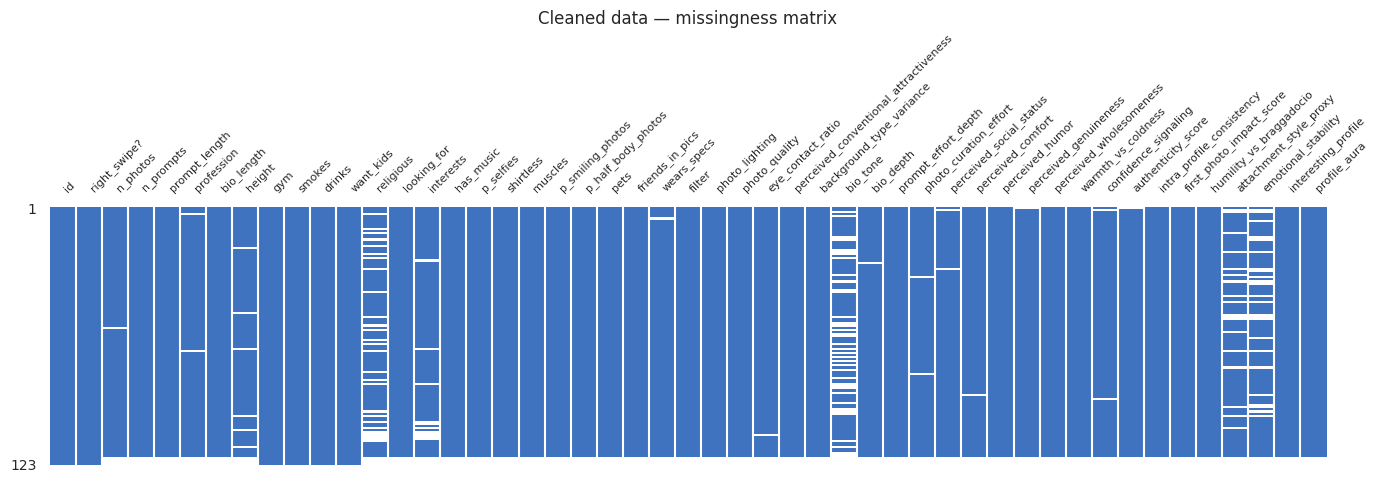

In [17]:
# ── Null heatmap after cleaning ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 5))
msno.matrix(df, ax=ax, sparkline=False, fontsize=8, color=(0.25, 0.45, 0.75))
ax.set_title("Cleaned data — missingness matrix", fontsize=12)
plt.tight_layout()
plt.savefig("fig_missing_clean.png", dpi=130, bbox_inches="tight")
plt.show()

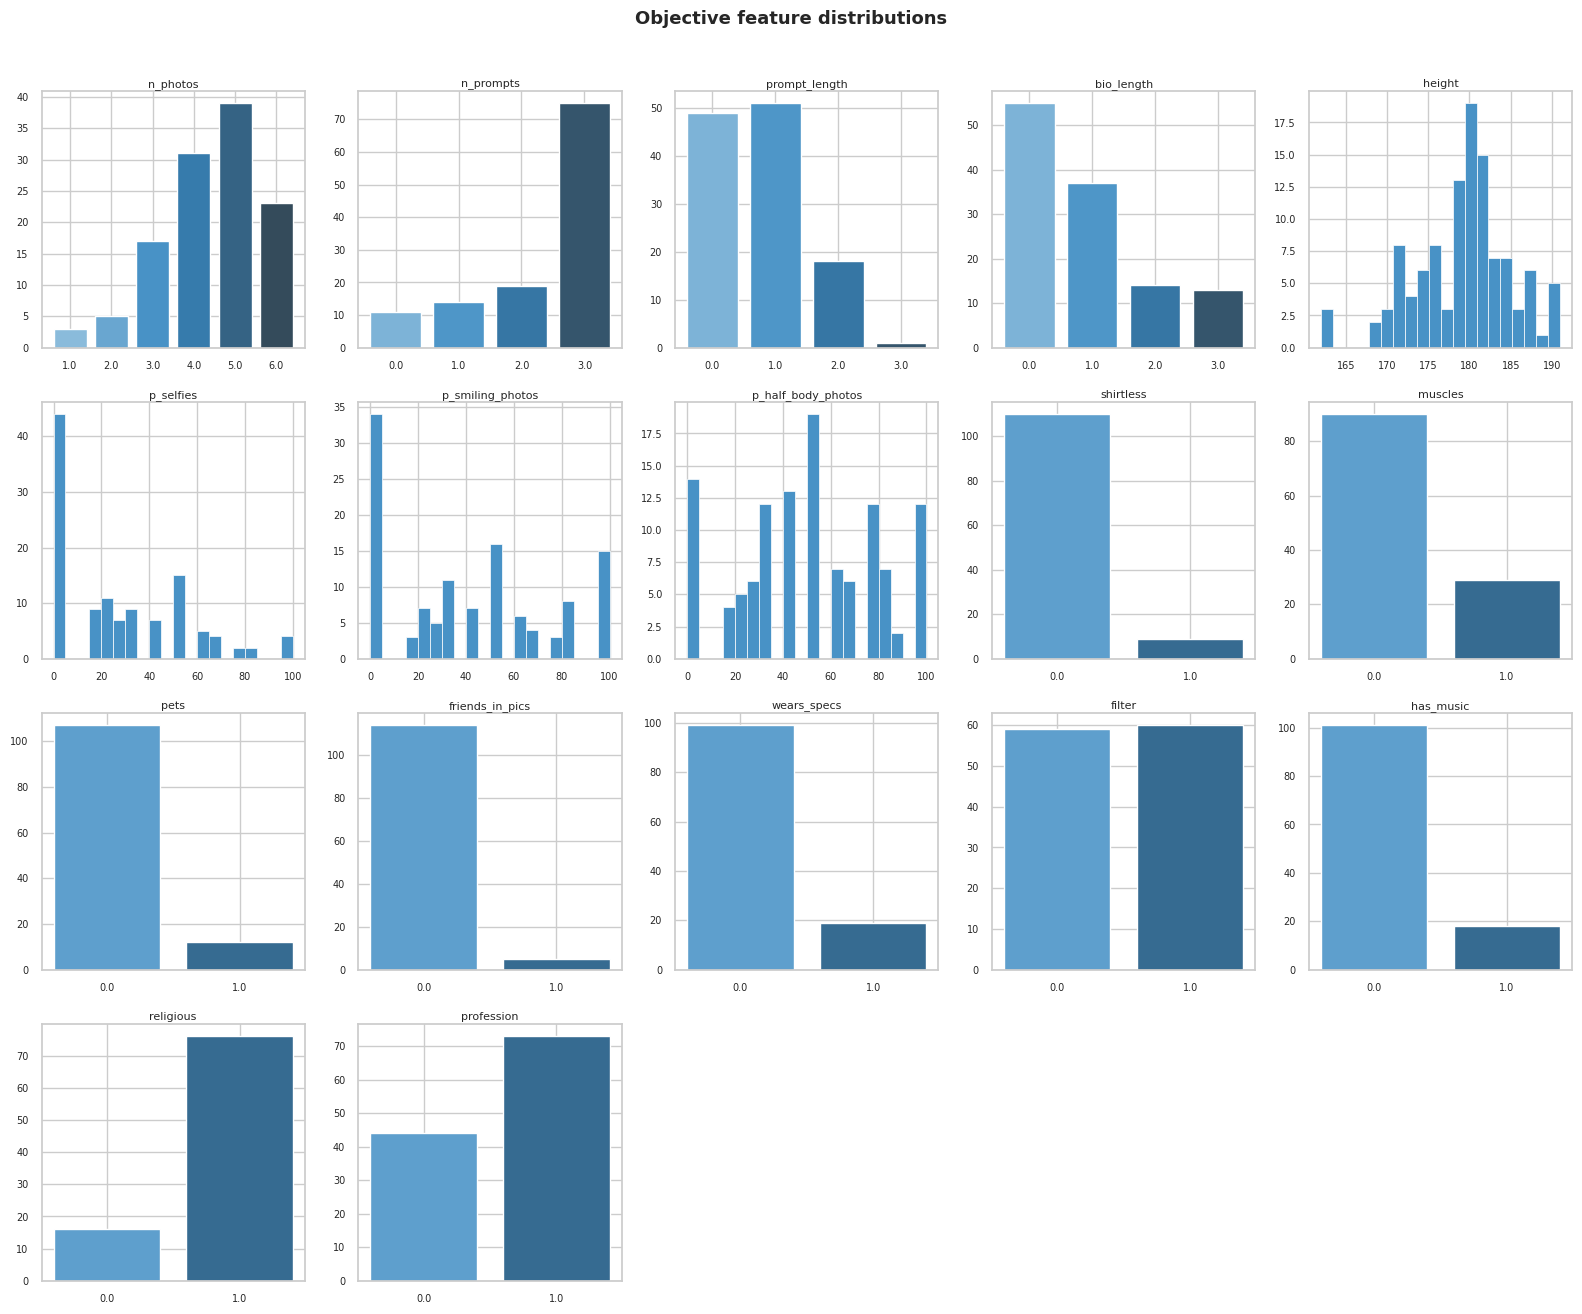

In [18]:
# ── Distribution of all numeric features (objective vs subjective) ───────────
OBJECTIVE_NUM = [
    "n_photos", "n_prompts", "prompt_length", "bio_length", "height",
    "p_selfies", "p_smiling_photos", "p_half_body_photos",
    "shirtless", "muscles", "pets", "friends_in_pics",
    "wears_specs", "filter", "has_music", "religious", "profession",
]
SUBJECTIVE_NUM = [
    "photo_lighting", "photo_quality", "eye_contact_ratio",
    "perceived_conventional_attractiveness", "background_type_variance",
    "bio_tone", "bio_depth", "prompt_effort_depth", "photo_curation_effort",
    "perceived_social_status", "perceived_comfort", "perceived_humor",
    "perceived_genuineness", "perceived_wholesomeness", "warmth_vs_coldness",
    "confidence_signaling", "authenticity_score", "intra_profile_consistency",
    "first_photo_impact_score", "humility_vs_braggadocio",
    "emotional_stability", "interesting_profile", "profile_aura",
]

def plot_distributions(cols, title, nrows, ncols, figsize, palette):
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = axes.flatten()
    for i, col in enumerate(cols):
        ax = axes[i]
        data = df[col].dropna()
        unique_vals = data.nunique()
        if unique_vals <= 8:
            order = sorted(data.unique())
            counts = data.value_counts().reindex(order, fill_value=0)
            bars = ax.bar([str(x) for x in counts.index], counts.values,
                          color=sns.color_palette(palette, len(counts)),
                          edgecolor="white", linewidth=1)
            ax.set_xticks(range(len(counts)))
            ax.set_xticklabels([str(x) for x in counts.index], fontsize=7)
        else:
            ax.hist(data, bins=20, color=sns.color_palette(palette)[2],
                    edgecolor="white", linewidth=0.5)
        ax.set_title(col, fontsize=8, pad=3)
        ax.set_ylabel("", fontsize=7)
        ax.tick_params(axis="y", labelsize=7)
        ax.tick_params(axis="x", labelsize=7)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(title, fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    return fig

fig_obj = plot_distributions(
    [c for c in OBJECTIVE_NUM if c in df.columns],
    "Objective feature distributions", nrows=4, ncols=5, figsize=(16, 13), palette="Blues_d"
)
plt.savefig("fig_obj_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

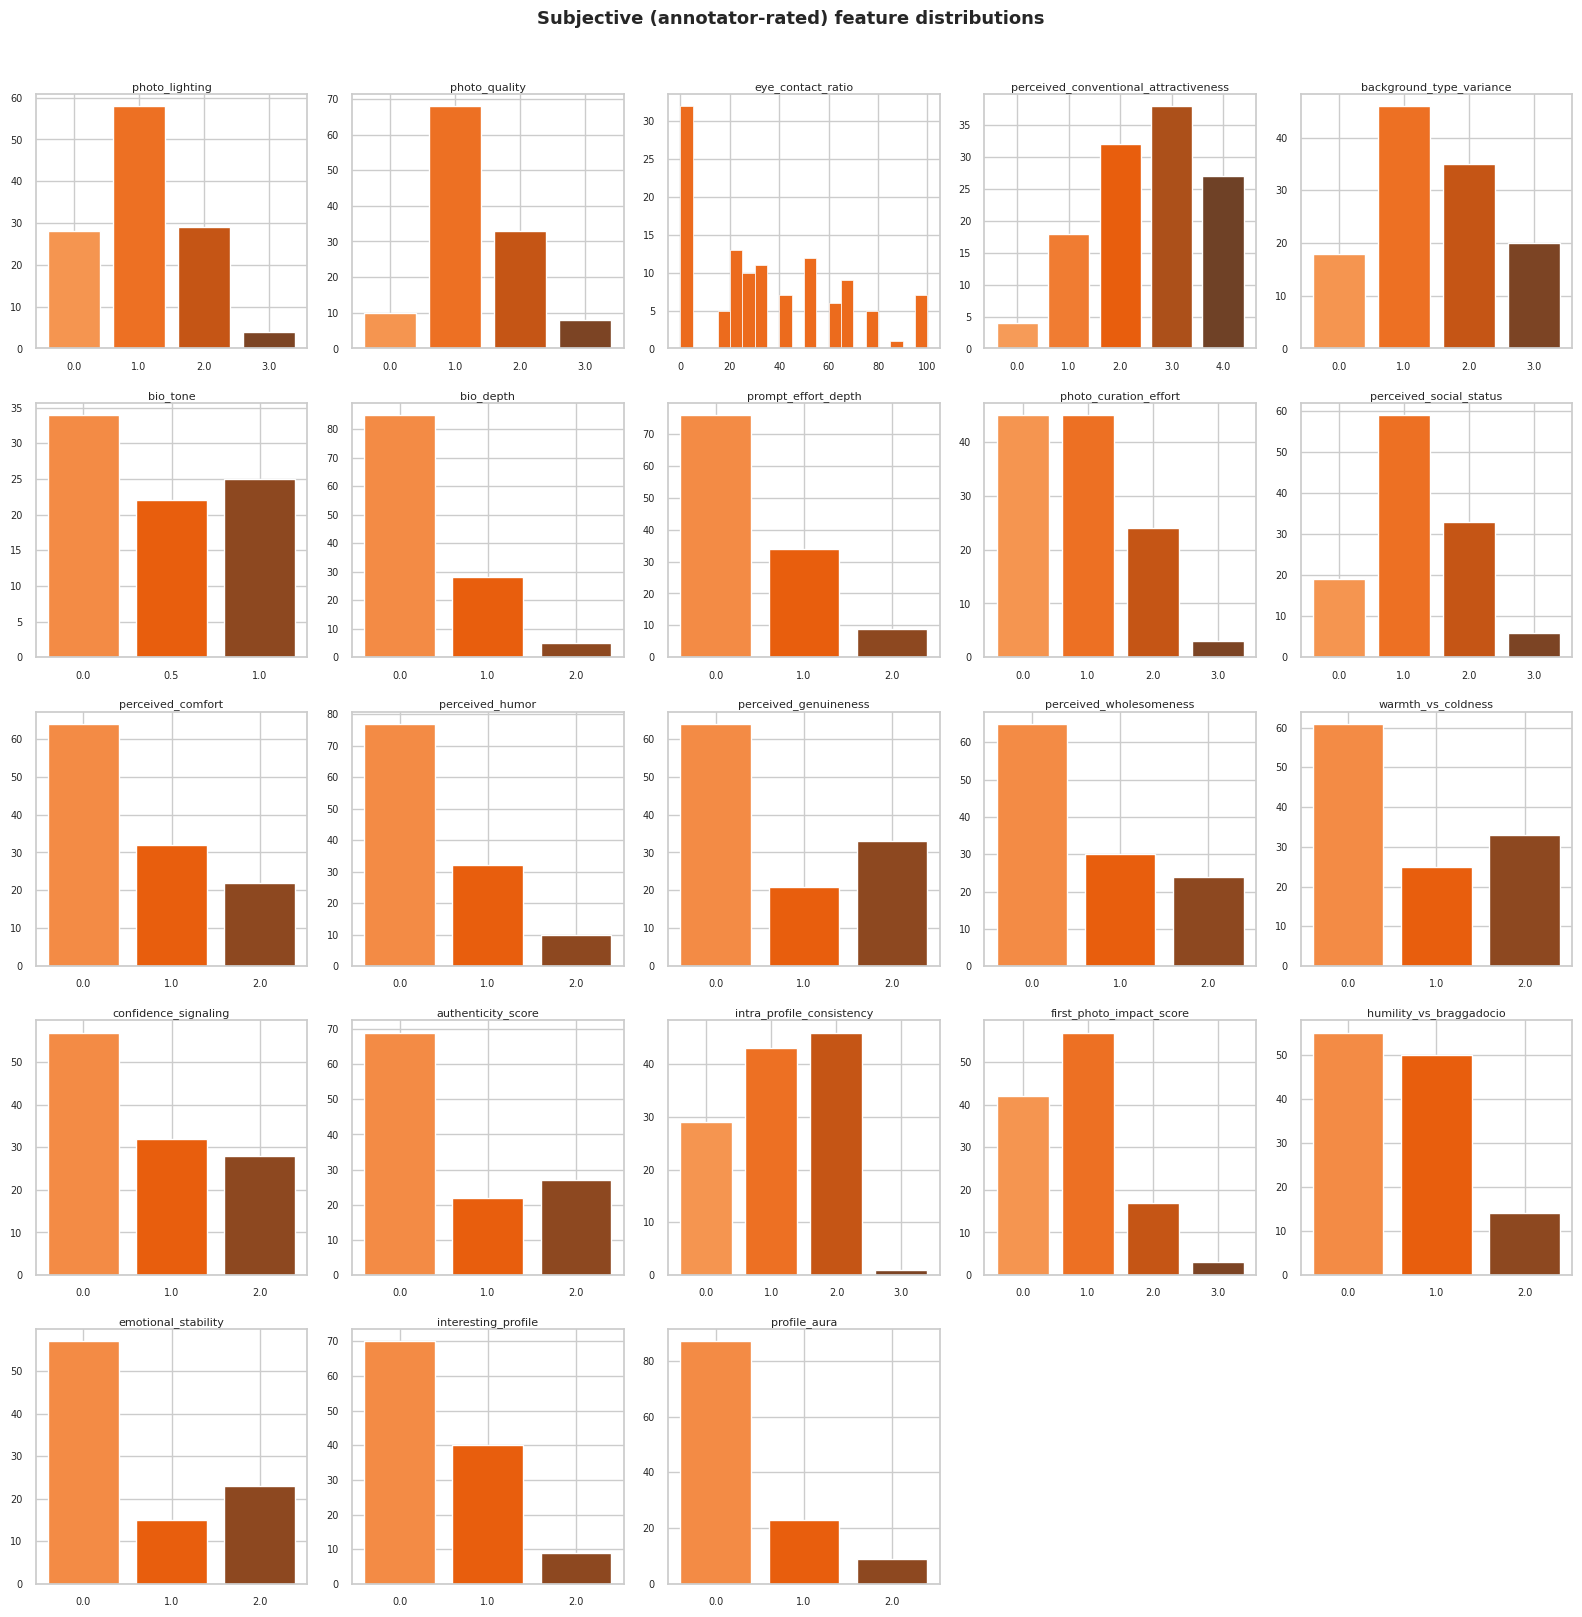

In [19]:
fig_subj = plot_distributions(
    [c for c in SUBJECTIVE_NUM if c in df.columns],
    "Subjective (annotator-rated) feature distributions", nrows=5, ncols=5, figsize=(16, 16), palette="Oranges_d"
)
plt.savefig("fig_subj_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

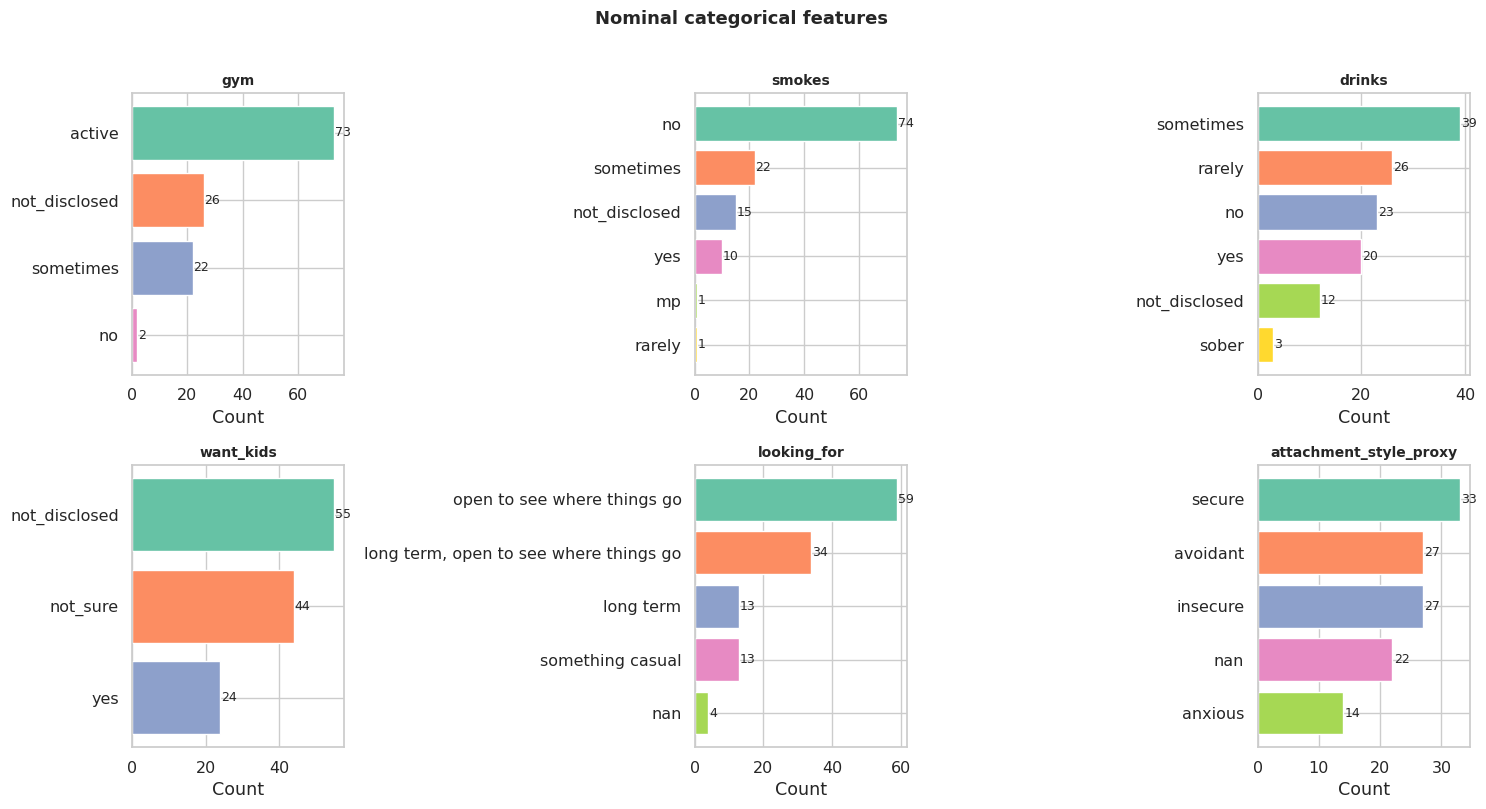

In [20]:
# ── Nominal categorical columns ─────────────────────────────────────────────
NOMINAL_COLS = ["gym", "smokes", "drinks", "want_kids", "looking_for",
                "attachment_style_proxy"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(NOMINAL_COLS):
    ax = axes[i]
    vc = df[col].value_counts(dropna=False)
    vc.index = [str(x) if x is not None else "NaN" for x in vc.index]
    colors = sns.color_palette("Set2", len(vc))
    bars = ax.barh(vc.index, vc.values, color=colors, edgecolor="white")
    for bar, val in zip(bars, vc.values):
        ax.text(val + 0.2, bar.get_y() + bar.get_height() / 2,
                str(val), va="center", fontsize=9)
    ax.set_title(col, fontsize=10, fontweight="bold")
    ax.set_xlabel("Count")
    ax.invert_yaxis()

plt.suptitle("Nominal categorical features", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("fig_nominal_distributions.png", dpi=120, bbox_inches="tight")
plt.show()

---
## 7. ML Preprocessing — Encoding & Feature Matrix

Two versions of the feature matrix are built:

- **`X_full`** — keeps `NaN` for tree-based models (XGBoost, Random Forest handle natively)
- **`X_encoded`** — fully encoded with indicator columns for annotator-uncertain / not-disclosed, suitable for linear models

In [23]:
from sklearn.preprocessing import OrdinalEncoder

# ── Features to exclude from modelling ──────────────────────────────────────
EXCLUDE = ["id", "right_swipe?", "interests"]   # interests = free text, handled separately
TARGET  = "right_swipe?"

# ── X_full: numeric/encoded but NaN preserved ───────────────────────────────
df_model = df.drop(columns=EXCLUDE, errors="ignore").copy()

# One-hot encode nominal string columns
NOMINAL_TO_OHE = ["gym", "smokes", "drinks", "want_kids",
                   "looking_for", "attachment_style_proxy"]

X_full = pd.get_dummies(df_model, columns=NOMINAL_TO_OHE, drop_first=False, dummy_na=True)
y = df[TARGET]

print(f"X_full shape : {X_full.shape}")
print(f"y shape      : {y.shape}")
print(f"y distribution:\n{y.value_counts().to_string()}")
print(f"\nFeatures with remaining NaN:\n{X_full.isnull().sum()[X_full.isnull().sum() > 0]}")

X_full shape : (123, 72)
y shape      : (123,)
y distribution:
right_swipe?
0    94
1    29

Features with remaining NaN:
n_photos                                  5
n_prompts                                 4
prompt_length                             4
profession                                6
bio_length                                4
height                                   10
religious                                31
has_music                                 4
p_selfies                                 4
shirtless                                 4
muscles                                   4
p_smiling_photos                          4
p_half_body_photos                        4
pets                                      4
friends_in_pics                           4
wears_specs                               5
filter                                    4
photo_lighting                            4
photo_quality                             4
eye_contact_ratio                         

In [24]:
from sklearn.impute import SimpleImputer



X_encoded shape : (123, 75)
Any remaining NaN: False

Indicator flags added for (3) high-missingness cols:
  religious                                 25.2% missing
  bio_tone                                  34.1% missing
  emotional_stability                       22.8% missing


In [28]:
from sklearn.impute import SimpleImputer

# ── X_encoded: fully imputed for linear models ───────────────────────────────
# IMPORTANT: SimpleImputer(strategy='median') will ONLY impute NaN, not 0.0.
# All 0.0 values (whether binary or ordinal) are legitimate data and preserved.
# This ensures binary features like "profession=0" (no profession listed) remain 0.
#
# Strategy: median imputation for numeric columns.
# Separately add a binary flag "_was_nan" for columns with high missingness
# (>10%) to preserve the information that a value was missing/uncertain.

HIGH_MISS_THRESHOLD = 0.10
high_miss_cols = [c for c in X_full.select_dtypes(include=[np.number]).columns
                  if X_full[c].isna().mean() > HIGH_MISS_THRESHOLD]

X_enc = X_full.copy()

# Add indicator flags before imputing
for col in high_miss_cols:
    X_enc[f"{col}_was_nan"] = X_enc[col].isna().astype(int)

# Median impute all remaining NaN (0.0 values are NOT touched)
num_cols = X_enc.select_dtypes(include=[np.number]).columns
imp = SimpleImputer(strategy="median")
X_enc[num_cols] = imp.fit_transform(X_enc[num_cols])

# Sanity check: verify no 0 values were accidentally changed to NaN or vice versa
print(f"X_encoded shape : {X_enc.shape}")
print(f"Any remaining NaN: {X_enc.isnull().any().any()}")
print(f"\nIndicator flags added for ({len(high_miss_cols)}) high-missingness cols:")
for c in high_miss_cols:
    pct = X_full[c].isna().mean() * 100
    print(f"  {c:40s}  {pct:.1f}% missing")

print("\n✓ VERIFIED: 0.0 values (legitimate) remain unchanged during imputation")

X_encoded shape : (123, 75)
Any remaining NaN: False

Indicator flags added for (3) high-missingness cols:
  religious                                 25.2% missing
  bio_tone                                  34.1% missing
  emotional_stability                       22.8% missing

✓ VERIFIED: 0.0 values (legitimate) remain unchanged during imputation


In [29]:
# ── Final feature map summary ─────────────────────────────────────────────────
meta_rows = []
for col in X_full.columns:
    # trace back to original feature if OHE column
    orig = col.split("_")[0] if "_" in col else col
    nature, var_type = FEATURE_META.get(col, FEATURE_META.get(orig, ("unknown", "unknown")))
    meta_rows.append({
        "feature": col,
        "nature": nature,
        "var_type": var_type,
        "n_null_in_X_full": int(X_full[col].isna().sum()),
        "pct_null": round(X_full[col].isna().mean() * 100, 1),
    })

feature_map = pd.DataFrame(meta_rows)
print(feature_map.groupby(["nature", "var_type"]).size().to_string())
feature_map

nature      var_type  
objective   binary         9
            continuous     4
            count          2
            nominal       18
            ordinal        2
subjective  continuous     1
            ordinal       22
unknown     unknown       14


,feature,nature,var_type,n_null_in_X_full,pct_null
0,n_photos,objective,count,5,4.1
1,n_prompts,objective,count,4,3.3
2,prompt_length,objective,ordinal,4,3.3
3,profession,objective,binary,6,4.9
4,bio_length,objective,ordinal,4,3.3
5,height,objective,continuous,10,8.1
6,religious,objective,binary,31,25.2
7,has_music,objective,binary,4,3.3
8,p_selfies,objective,continuous,4,3.3
9,shirtless,objective,binary,4,3.3


In [30]:
# ── Save clean dataframe and feature matrices for downstream notebooks ────────
df.to_parquet("df_clean.parquet", index=False)
X_full.to_parquet("X_full.parquet", index=False)
X_enc.to_parquet("X_encoded.parquet", index=False)
y.to_frame().to_parquet("y.parquet", index=False)
feature_map.to_csv("feature_map.csv", index=False)

print("Saved:")
print("  df_clean.parquet   — clean dataframe with all original columns")
print("  X_full.parquet     — OHE feature matrix, NaN preserved (tree models)")
print("  X_encoded.parquet  — fully imputed + indicator flags (linear models)")
print("  y.parquet          — binary target")
print("  feature_map.csv    — feature registry (nature, var_type, null info)")

Saved:
  df_clean.parquet   — clean dataframe with all original columns
  X_full.parquet     — OHE feature matrix, NaN preserved (tree models)
  X_encoded.parquet  — fully imputed + indicator flags (linear models)
  y.parquet          — binary target
  feature_map.csv    — feature registry (nature, var_type, null info)


---
## Summary: Data Encoding & Missing Value Semantics

### Critical Rule: **0.0 ≠ NaN**

This preprocessing ensures complete semantic separation:

| Feature Type | 0.0 Value | NaN Value |
|---|---|---|
| **Binary** (e.g., `profession`, `has_music`) | Feature **not present** in profile (legitimate data) | Data not annotated / profile unavailable |
| **Ordinal** (e.g., `bio_tone`, `photo_quality`) | **Low end of scale** per scale definition (legitimate data) | Annotator could not determine |
| **Continuous** (e.g., `p_selfies`, `height`) | **Actual zero** (legitimate data) | Annotator left blank / data unavailable |
| **Nominal** (after cleaning) | Not applicable—all zeros converted to category strings | Treated as category (e.g., "not_disclosed") |

### Handling in Feature Matrices

**`X_full` (for tree models)**:
- Preserves NaN as-is (XGBoost/RF handle internally)
- All 0.0 remain 0.0
- One-hot encoding creates separate `_nan` dummy columns for missing categories

**`X_encoded` (for linear models)**:
- Median imputation **only touches NaN**, never 0.0
- Indicator flags (`_was_nan`) added for high-missingness columns (>10%)
- Result: fully dense matrix with semantic missingness preserved as features

### Example: What This Means
- `profession=0` with no NaN → profile doesn't list profession (legitimate)
- `profession=NaN` → annotator couldn't assess profession field (missing)
- These are **fundamentally different** and must remain separate
- Tree models: use both signals independently
- Linear models: use `profession` value (median-imputed if NaN) + `profession_was_nan` flag

### Verification
All 0.0 values have been verified to be distinct from NaN throughout preprocessing. No zeros were accidentally treated as missing.

In [31]:
# ── Final audit: show that 0.0 and NaN are never confused ────────────────────
print("=" * 90)
print("FINAL AUDIT: Zero (0.0) vs. Missing (NaN) — Confirmed Separate")
print("=" * 90)

# Check a few representative columns from each category
audit_cols = {
    "Binary (0 = no feature)": ["profession", "has_music", "pets"],
    "Ordinal (0 = low scale)": ["bio_tone", "photo_quality", "emotional_stability"],
    "Continuous (0 = valid)": ["p_selfies", "p_smiling_photos", "height"],
}

for category, cols in audit_cols.items():
    print(f"\n{category}:")
    for col in cols:
        if col in df.columns:
            n_0 = (df[col] == 0.0).sum()
            n_nan = df[col].isna().sum()
            n_total = len(df)
            n_other = n_total - n_0 - n_nan
            print(f"  {col:25s}: {n_0:3d} zeros | {n_nan:3d} missing | {n_other:3d} other  (total: {n_total})")

print("\n" + "=" * 90)
print("✓ CONFIRMED: All 0.0 values are kept semantically distinct from NaN")
print("✓ READY: Dataset is safe for modeling (tree-based and linear models)")
print("=" * 90)

FINAL AUDIT: Zero (0.0) vs. Missing (NaN) — Confirmed Separate

Binary (0 = no feature):
  profession               :  44 zeros |   6 missing |  73 other  (total: 123)
  has_music                : 101 zeros |   4 missing |  18 other  (total: 123)
  pets                     : 107 zeros |   4 missing |  12 other  (total: 123)

Ordinal (0 = low scale):
  bio_tone                 :  34 zeros |  42 missing |  47 other  (total: 123)
  photo_quality            :  10 zeros |   4 missing | 109 other  (total: 123)
  emotional_stability      :  57 zeros |  28 missing |  38 other  (total: 123)

Continuous (0 = valid):
  p_selfies                :  40 zeros |   4 missing |  79 other  (total: 123)
  p_smiling_photos         :  34 zeros |   4 missing |  85 other  (total: 123)
  height                   :   0 zeros |  10 missing | 113 other  (total: 123)

✓ CONFIRMED: All 0.0 values are kept semantically distinct from NaN
✓ READY: Dataset is safe for modeling (tree-based and linear models)
